In [2]:
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from kneed import KneeLocator
from yellowbrick.cluster import KElbowVisualizer
from sklearn.cluster import KMeans, AgglomerativeClustering

---
## <u>Load Dataset</u>

In [3]:
data = pd.read_csv("smartcart_customers.csv")
data.isnull().sum() # shows 24 in income column
data.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


---
## <u>Handle Missing Values<u>

In [4]:
knn_imputer = KNNImputer(n_neighbors = 5)
data["Income"] = knn_imputer.fit_transform(data[["Income"]]) # knn imputer needs 2d data as input thats why double brackets

data.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Complain               0
Response               0
dtype: int64

---
## <u>Feature Engineering<u>

1. Dates arent handled well in both supervised/unsupervised ML so we need to convert them into some numerical form.
    - We will make more meaningful features instead of birth_year and Dt_Customer :-
        - from birth_year we can get age of the customer
        - from Dt_Customer we can get the number of days the customer has been enrolled to the platform          

In [ ]:
# Age 
# pd.to_datetime("today") gives today's date and time like 08-30-2026 14:06:21
# .year feature gets the year like 2026
data["Age"] = (pd.to_datetime("today")).year - data["Year_Birth"]

# Customer Tenure
# we convert Dt_Customer to datetime object so that it is subtractable from pd.to_datetime("today"), we ensure the dd-mm-yyyy format
data["Dt_Customer"] = pd.to_datetime(data["Dt_Customer"], dayfirst=True)
data["Customer_Tenure"] = (pd.to_datetime("today") - data["Dt_Customer"]).dt.days

2. As we are focusing on customer segmentation in this case, we will combine all the spending columns into one single "total" column
    - total_spending = MntWines + MntFruits + MntMeatProducts + MntFishProducts + MntSweetProducts + MntGoldProds

In [ ]:
# total spending
data["total_spending"] = data["MntWines"] + data["MntFruits"] + data["MntMeatProducts"] + data["MntFishProducts"] + data["MntSweetProducts"] + data["MntGoldProds"]

3. There are 2 categories of kids at home and teenagers at home so we combine them as childen at home
    - children_home = Kidhome + Teenhome

In [ ]:
# children at home
data["children_home"] = data["Kidhome"] + data["Teenhome"]

4. There are 5 subcategories in Education column so replace them with 3 subcategories only
    - undergraduate = 2n cycle + basic
    - graduate = Graduation
    - post_graduate = phd + masters

In [ ]:
# Education 
data["Education"].value_counts() # tells how many different values are there in this category
data["Education"] = data["Education"].replace({ # replaces the categories in the column as a dictionary
                    "Basic" : "Undergraduate",
                    "2n Cycle" : "Undergraduate",
                    "Graduation" : "Graduate",
                    "PhD" : "Postgraduate",
                    "Master" : "Postgraduate"
})

5. There are 8 sub categories in marital status column so we make a new column called "Living_With" and it will have only 2 sub categories
    - partner = Married + Alone
    - alone = Single + Divorced + Widow + Alone + Absurd + YOLO

In [5]:
# Marital Status
data["Marital_Status"].value_counts()
data["Living_With"] = data["Marital_Status"].replace({
    "Married" : "Partner",
    "Together" : "Partner",
    "Single" : "Alone",
    "Divorced" : "Alone",
    "Widow" : "Alone",
    "Absurd" : "Alone",
    "YOLO" : "Alone"
})

---
## <u>Drop Columns<u>

- now we drop the unneccesary columns in our dataset

In [6]:
X = data.drop(columns=['ID', 'Year_Birth', 'Marital_Status', 'Kidhome', 'Teenhome', 'Dt_Customer',  'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds'])
X.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure,total_spending,children_home,Living_With
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,5109,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,4559,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,4758,776,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,4585,53,1,Partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,4607,422,1,Partner


---
## <u>Outlier Detection<u>

- we will first use boxplots to see it there are any outliers

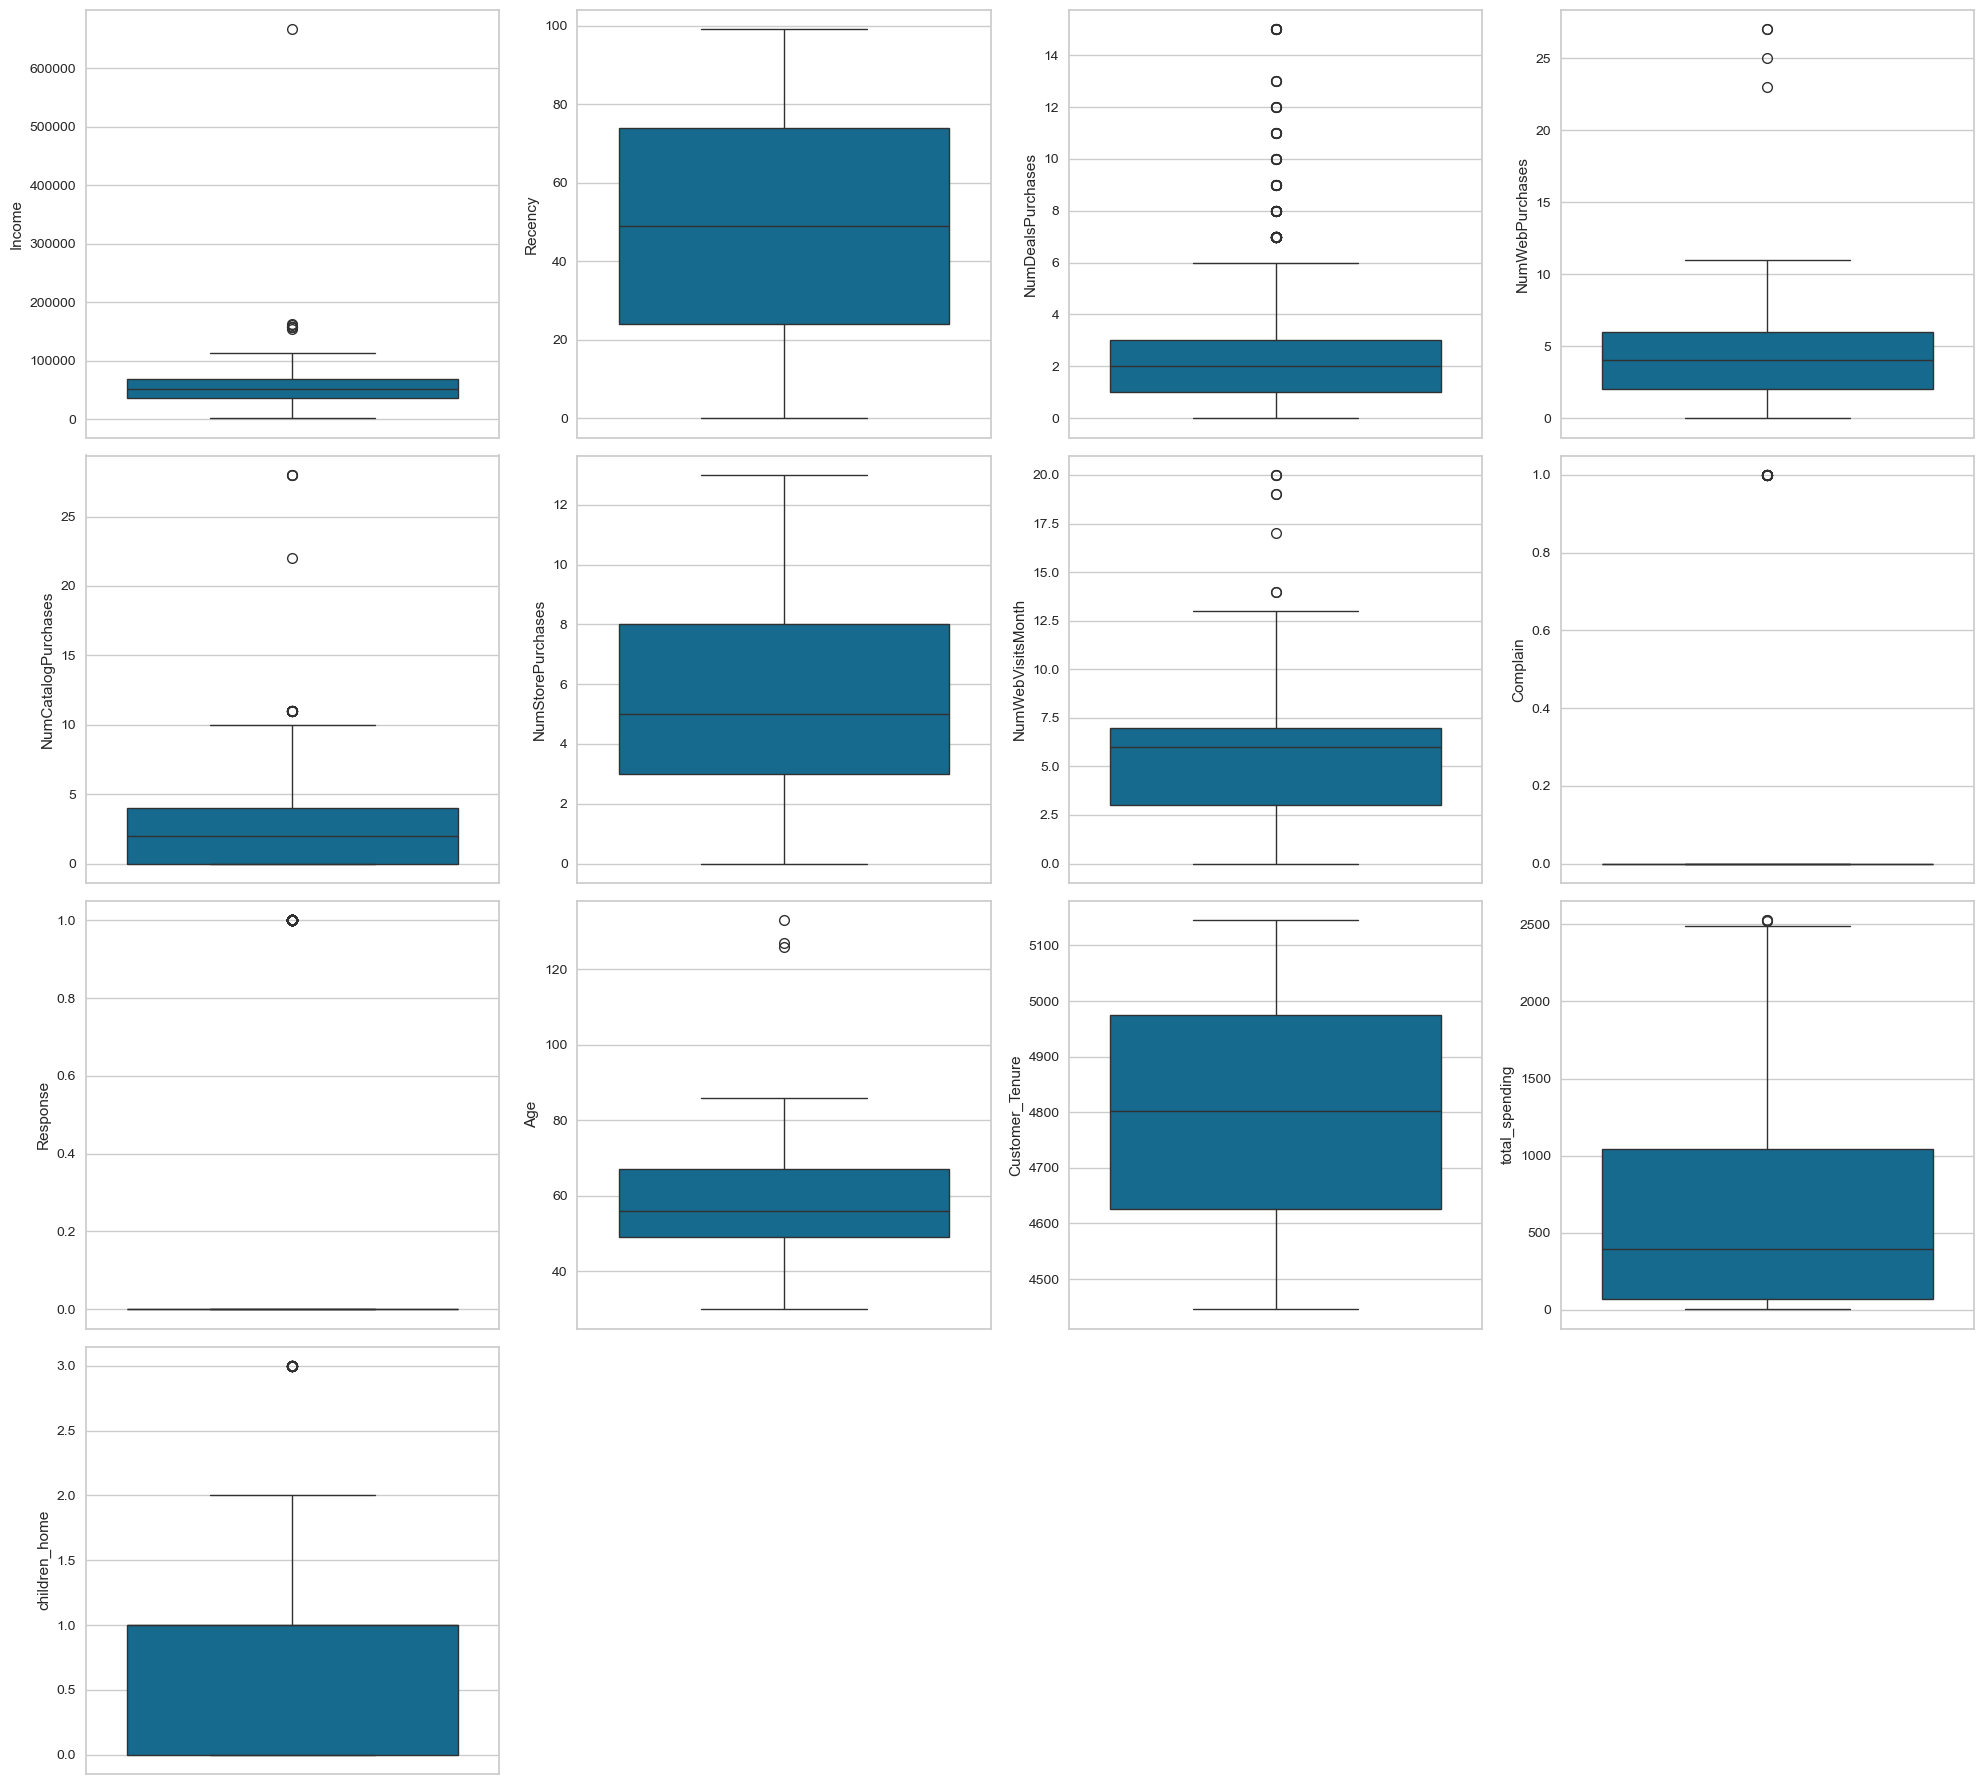

In [7]:
num_cols = X.select_dtypes(include=["number"]).columns

# define figure and axes
fig, ax = plt.subplots(4,4,figsize=(20,18))

# making boxplots using loops
n = 0
for i in range(4): # for rows
    for j in range(4): # for cols
        if n < len(num_cols): # to make only 13 columns and not 16
            sns.boxplot(
                ax=ax[i, j],
                y=data[num_cols[n]] # to make the plots vertical 
            )
            n = n + 1
        else:
            # Hide the extra empty subplots
            ax[i, j].set_visible(False)

plt.tight_layout()
# plt.savefig("Box_plots_Numerical_Cols")
plt.show()

Key Findings :-

1. There is some natural variance dataset among numerical categories and we will keep it but there are a few outliers like
    - income : 1 person has income 600,000 
    - age : 4 people have age above 100

In [8]:
X_cleaned = X[(X["Income"] < 300000) & (X["Age"] < 100)] 
print("Entries with outliers : ", len(X))
print("Entries after removing outliers", len(X_cleaned))
X_cleaned.head()

Entries with outliers :  2240
Entries after removing outliers 2236


,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure,total_spending,children_home,Living_With
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,5109,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,4559,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,4758,776,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,4585,53,1,Partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,4607,422,1,Partner


---
## <u>Correlation Heatmap</u>

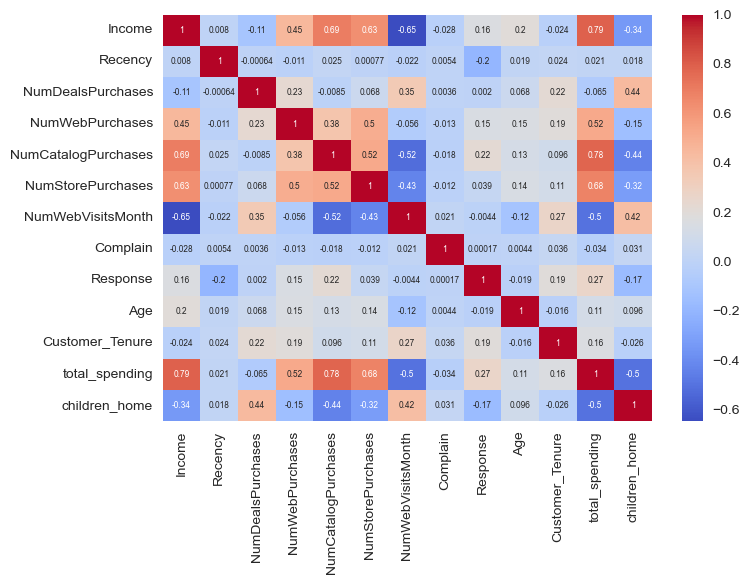

In [9]:
corr_matrix = X_cleaned.corr(numeric_only = True) # takes only numeric columns
plt.figure(figsize=(8,6))
sns.heatmap(
    corr_matrix,
    annot = True, # the annotations (values) should be visible
    annot_kws = {"size" : 6}, # changes the font size of the correlation numbers to 6
    cmap = "coolwarm"
)

plt.tight_layout()
# plt.savefig("Correlation_heatmap_numcols")
plt.show()

### Key Findings

- Top 5 Positive Correlations:

    - Income & total_spending (0.79): Customers with higher incomes spend significantly more across all product categories.

    - NumCatalogPurchases & total_spending (0.78): High total spenders are heavily driven by frequent catalog purchases.

    - Income & NumCatalogPurchases (0.69): Wealthier customers are much more likely to utilize catalogs for their shopping.
    
    - NumStorePurchases & total_spending (0.68): Frequent physical store visits consistently result in higher overall customer spending.
    
    - Income & NumStorePurchases (0.63): Customers earning higher incomes tend to make more frequent in-store purchases.
 
- Top 5 Negative Correlations:

   - Income & NumWebVisitsMonth (-0.65): Higher-income customers visit the company website much less frequently than lower-income customers.
    
    - NumCatalogPurchases & NumWebVisitsMonth (-0.52): Customers who heavily rely on catalog shopping rarely browse the website.
    
   -  NumWebVisitsMonth & total_spending (-0.50): High website traffic does not translate to revenue, as frequent visitors actually spend less overall.
    
    - total_spending & children_home (-0.50): Customers with more children living at home have noticeably lower overall spending habits.
    
    - NumCatalogPurchases & children_home (-0.44): Households with more children are much less likely to make purchases through catalogs.

---
## <u>Preprocessing</u>

- encoding and scaling basically

In [10]:
num_cols = X_cleaned.select_dtypes(include=["number"]).columns
cat_cols = X_cleaned.select_dtypes(include=["category","object"]).columns

# Encoding 
encoder = ColumnTransformer(
    transformers=[
        # sparse output false to make sure that it returns a proper arrat rather than a sparse matrix coordinates
        ("ohe", OneHotEncoder(sparse_output=False, handle_unknown="ignore"), cat_cols)  
    ],
    remainder="passthrough", # so that the other columns(num_cols) are ignored and passed through
    verbose_feature_names_out=False # Prevents prefixes like "ohe__" etc
)
encoder.set_output(transform="pandas")

X_encoded = encoder.fit_transform(X_cleaned)

# Scale 
scaler = ColumnTransformer(
    transformers=[
        ("scaler", StandardScaler(), num_cols) 
    ],
    remainder="passthrough", # # so that the other columns(cat_cols) are ignored and passed through
    verbose_feature_names_out=False # Prevents prefixes like "scaler__" etc
)
scaler.set_output(transform="pandas")

X_scaled = scaler.fit_transform(X_encoded)

X_scaled.head()

---
## <u>Visualise</u>

In [26]:
pca = PCA(n_components = 8)
pca.set_output(transform = "pandas")
X_pca = pca.fit_transform(X_scaled)
print("Variance Kept : ", pca.explained_variance_ratio_.sum())

Variance Kept :  0.823088289768115


Text(0.5, 0.92, '3d projection')

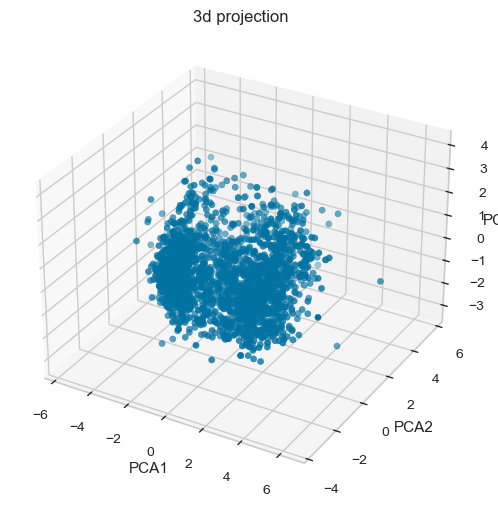

In [29]:
# plot
fig = plt.figure(figsize=(8, 6))

ax = fig.add_subplot(1,1,1, projection="3d") # 1 row, 1 column, 1st position, projection shall be 3d

ax.scatter( 
    xs = X_pca.iloc[:, 0], # for 3D scatter plots using ax.scatter, we pass axes as xs, ys and zs rather than x, y, z
    ys = X_pca.iloc[:, 1], 
    zs = X_pca.iloc[:, 2])

ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3d projection")

---
## <u>Choosing K<u>

1. Elbow Method
2. Silhoutte Score

3. Calinski-Harabasz method :-
- ratio of the variance between clusters to the variance within clusters, adjusted for the number of clusters and data points.
- used to determine the optimal number of clusters (k) by analyzing how compact and well-separated the groups
    - Variance BETWEEN clusters/ Variance WITHIN clusters

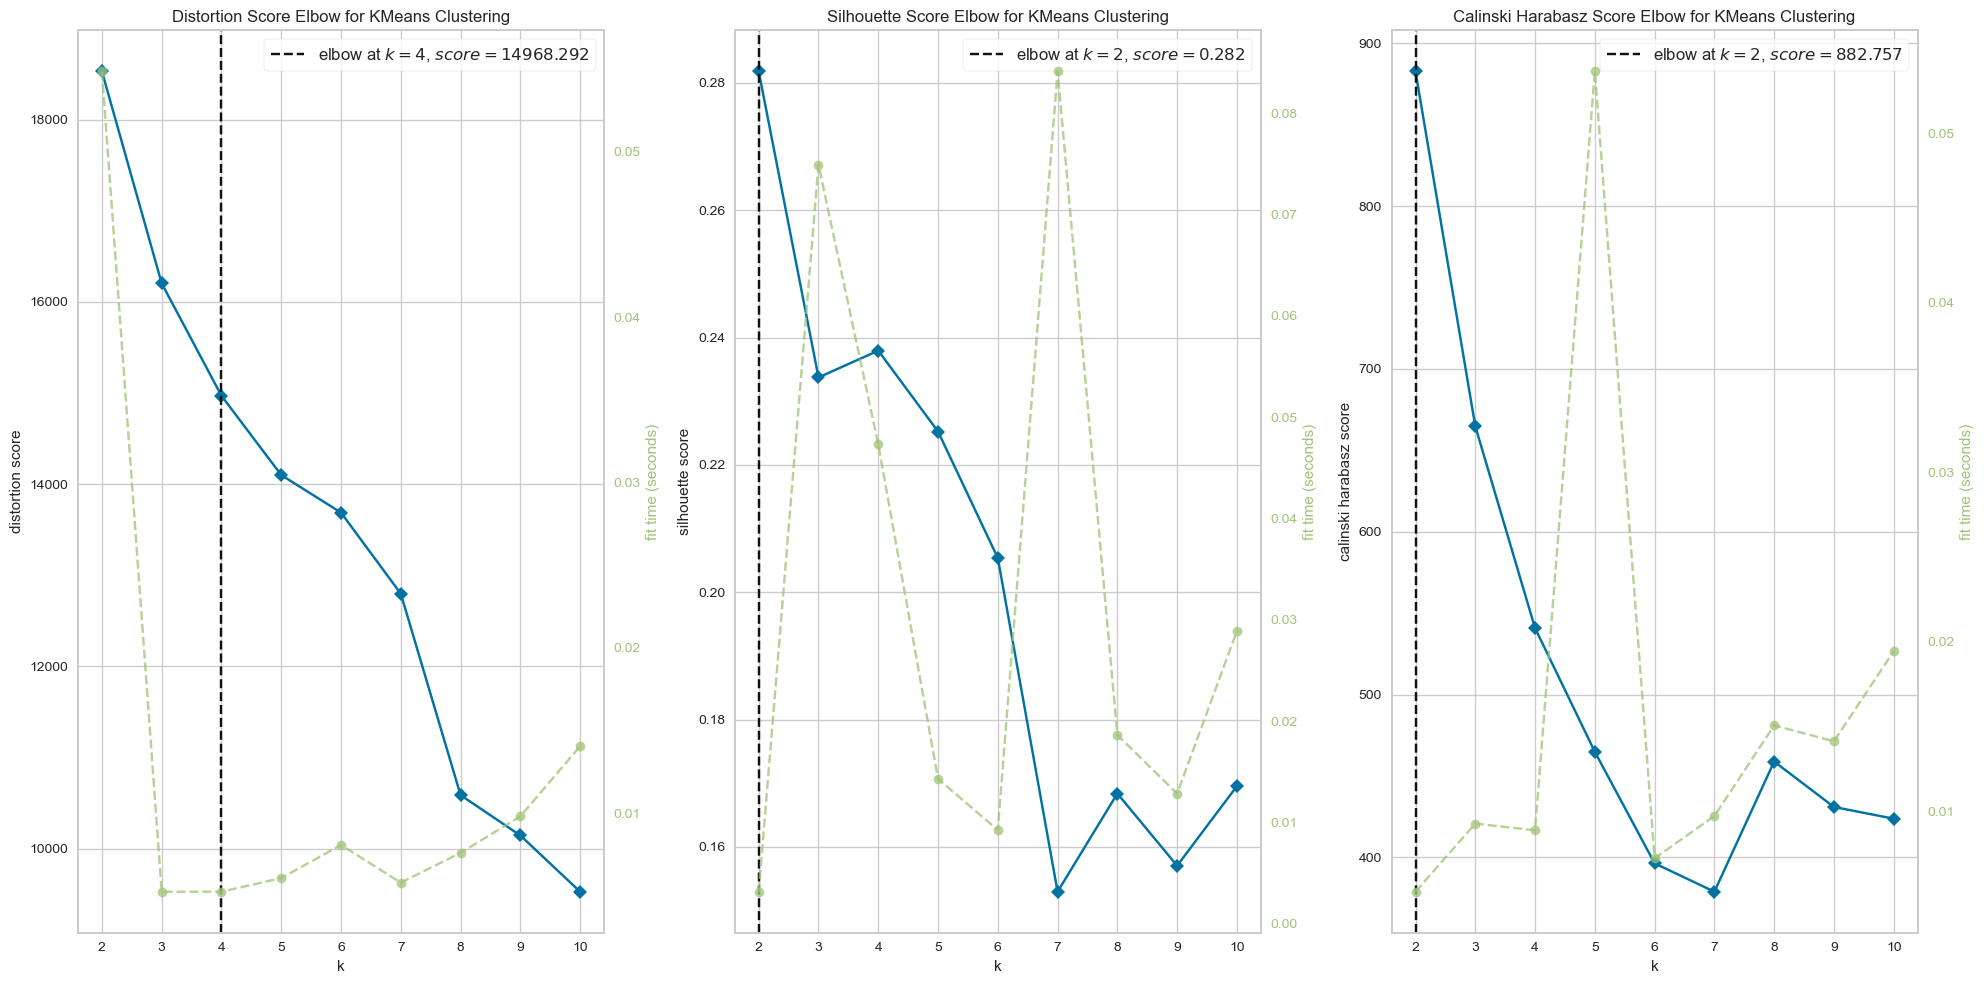

In [30]:
fig, ax = plt.subplots(1,3,figsize=(20,10))

# always use the range for k as 1 to 10 or 2 to 10 only 

# 1. Elbow method
elbow_visualizer = KElbowVisualizer(KMeans(random_state=42), k=(2, 11), ax=ax[0])
elbow_visualizer.fit(X_pca)
elbow_visualizer.finalize() # finalize() instead of show() to safely attach it to ax[0]

# 2. Silhouette Score 
sil_visualizer = KElbowVisualizer(KMeans(random_state=42), k=(2, 11), metric="silhouette", ax=ax[1])
sil_visualizer.fit(X_pca)
sil_visualizer.finalize()

# 3. Calinski-Harabasz 
ch_visualizer = KElbowVisualizer(KMeans(random_state=42), k=(2, 11), metric="calinski_harabasz", ax=ax[2])
ch_visualizer.fit(X_pca)
ch_visualizer.finalize()

plt.tight_layout()
# plt.savefig("Finding_Optimal_K")
plt.show()

---
## <u>Make and Visualise Different Models to Evaluate</u>

- we will make a total of 6 models, with 3 k values and 2 ML Algorithms
- No DBSCAN here as it specialises in non-linear datasets and for anomaly detection

1. KMeans Clustering

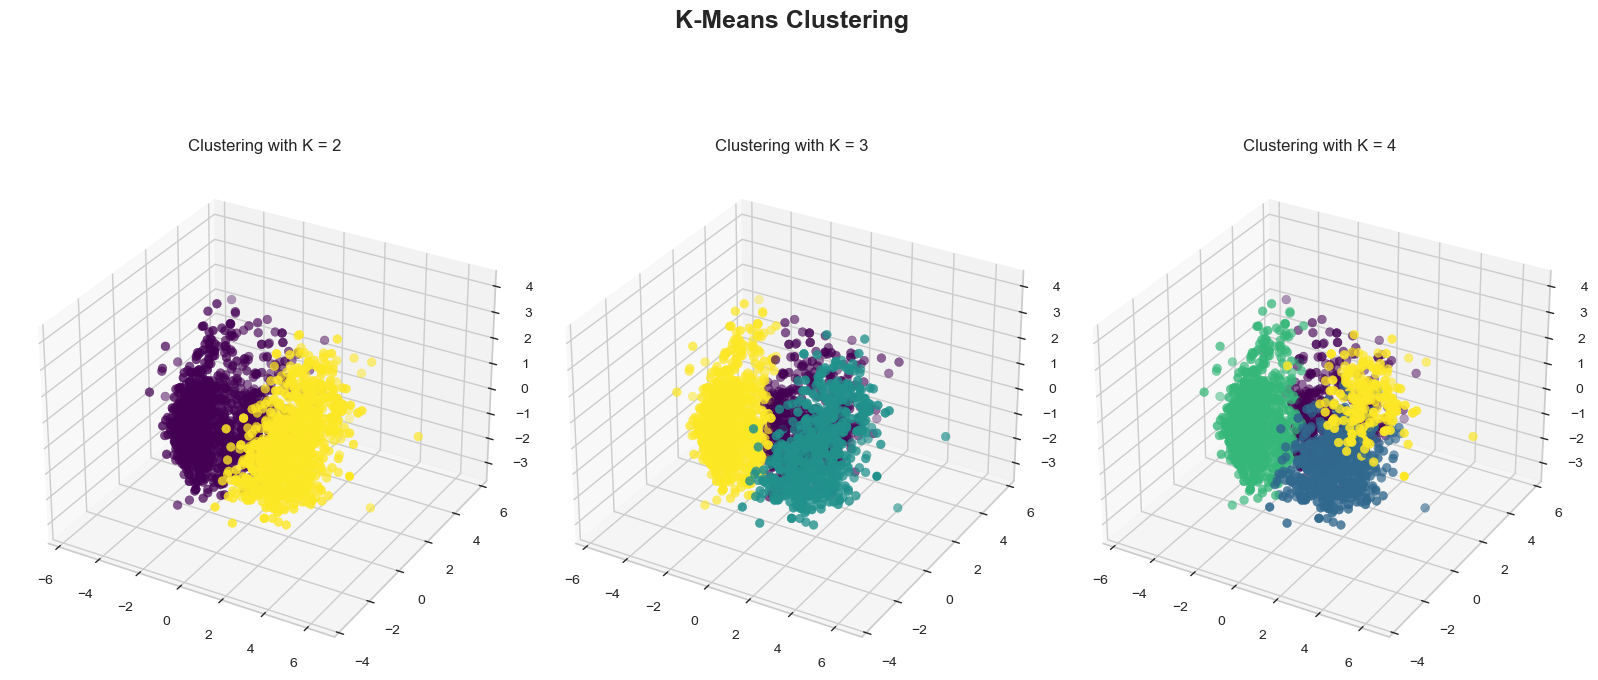

In [15]:
k = [2, 3, 4]

# Create a figure to fit 3 plots 
fig = plt.figure(figsize=(16, 8))
fig.suptitle("K-Means Clustering", fontsize=18, fontweight="bold")
for i in range(3):
    
    # Initialize a 3D subplot for each K, i + 1 is the position for a particular k, like when i = 0 (for k = 2), the position is 1
    ax = fig.add_subplot(1, 3, i+1, projection="3d")
    
    kmeans = KMeans(
        n_clusters=k[i],
        random_state=42
    )

    labels_kmeans = kmeans.fit_predict(X_pca)
    
    ax.scatter(
        xs = X_pca.iloc[:, 0], 
        ys = X_pca.iloc[:, 1], 
        zs = X_pca.iloc[:, 2],
        c=labels_kmeans,
        cmap="viridis", 
        s=40 # Point size
    )

    ax.set_title(f"Clustering with K = {k[i]}")

plt.tight_layout()
# plt.savefig("KMeans_Clustering_234")
plt.show()

2. Heirarchial (Agglomerative) Clustering

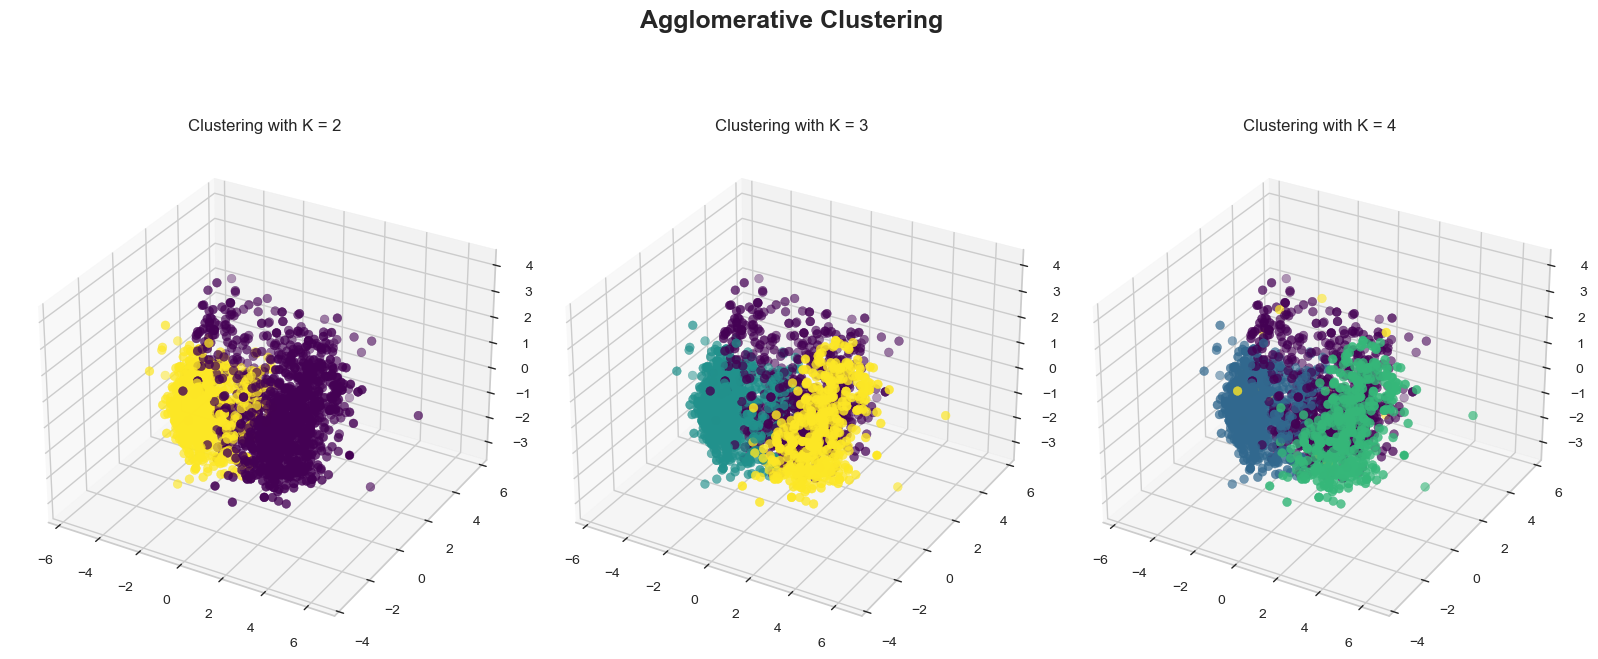

In [16]:
fig = plt.figure(figsize = (16,8))

for i in range(3):

    ax = fig.add_subplot(1,3,i+1,projection = "3d")

    agg_model = AgglomerativeClustering(
        n_clusters = k[i],
        linkage = "ward"
    )

    labels_agg = agg_model.fit_predict(X_pca)

    ax.scatter(
        xs = X_pca.iloc[:,0],
        ys = X_pca.iloc[:,1],
        zs = X_pca.iloc[:,2],
        c = labels_agg,
        cmap = "viridis",
        s = 40
    )

    ax.set_title(f"Clustering with K = {k[i]}")

plt.tight_layout()
fig.suptitle("Agglomerative Clustering", fontsize=18, fontweight="bold")
# plt.savefig("Agg_Clustering_234")
plt.show()

### Key Findings :-

- The clearest separation is at K=2 for KMeans clustering so thats what we will take for characterization of clusters

---

## <u>Characterization Of Clusters<u>

- using k = 2, KMeans Clustering

In [21]:
pd.options.mode.copy_on_write = True # Pandas will now automatically & safely copy the data when we add labels column

# Making the actual model
kmeans_2 = KMeans(
    n_clusters = 2,
    random_state = 42
)

labels_kmeans_2 = kmeans_2.fit_predict(X_pca)

# Appending the labels to the dataset
X_encoded["Labels"] = labels_kmeans_2 # using X encoded as it just has numbers (unscaled so easy for us) fo clustering summary
X_encoded.head()

,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure,total_spending,children_home,Labels
0,1.0,0.0,0.0,1.0,0.0,58138.0,58,3,8,10,4,7,0,1,69,5109,1617,0,1
1,1.0,0.0,0.0,1.0,0.0,46344.0,38,2,1,1,2,5,0,0,72,4559,27,2,0
2,1.0,0.0,0.0,0.0,1.0,71613.0,26,1,8,2,10,4,0,0,61,4758,776,0,1
3,1.0,0.0,0.0,0.0,1.0,26646.0,26,2,2,0,4,6,0,0,42,4585,53,1,0
4,0.0,1.0,0.0,0.0,1.0,58293.0,94,5,5,3,6,5,0,0,45,4607,422,1,0


<Axes: xlabel='Labels', ylabel='count'>

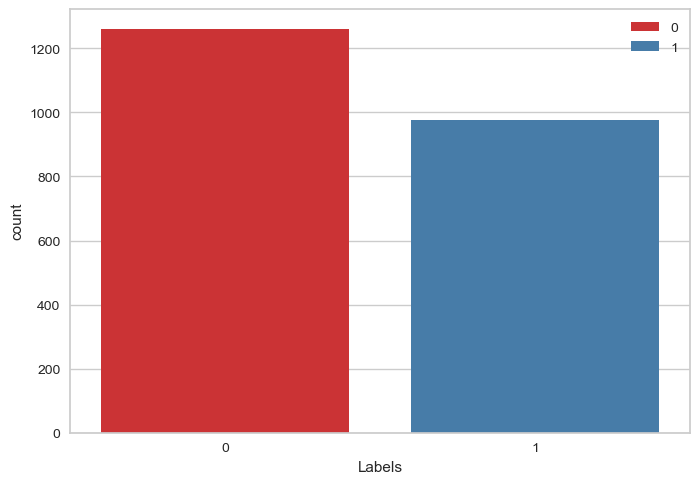

In [31]:
# creating a count plot to see how many data points in each cluster
sns.countplot(
    x = X_encoded["Labels"],
    palette = "Set1",
    hue = labels_kmeans_2
    
)

<Axes: xlabel='total_spending', ylabel='Income'>

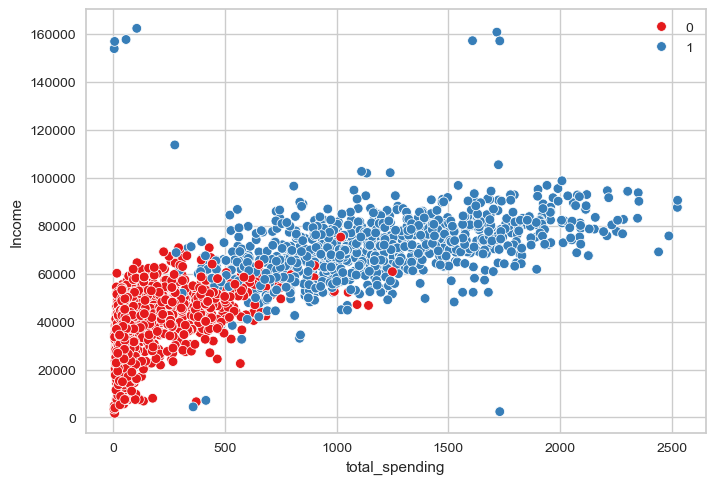

In [23]:
# Comparing the two most imp features to find some patterns : income and spending 
sns.scatterplot(
    x = X_encoded["total_spending"],
    y = X_encoded["Income"],
    hue = labels_kmeans_2,
    palette = "Set1"
)

plt.savefig("Spending vs Income")

In [24]:
# Cluster Summary

cluster_summary = X_encoded.groupby("Labels").mean()
print(cluster_summary)

        Education_Graduate  Education_Postgraduate  Education_Undergraduate  \
Labels                                                                        
0                 0.491660                0.365369                 0.142971   
1                 0.518936                0.404299                 0.076766   

        Living_With_Alone  Living_With_Partner        Income    Recency  \
Labels                                                                    
0                0.347895             0.652105  37328.541122  48.811755   
1                0.364381             0.635619  70819.027389  49.508700   

        NumDealsPurchases  NumWebPurchases  NumCatalogPurchases  \
Labels                                                            
0                2.540111         2.799047             0.791898   
1                2.050154         5.748209             5.074719   

        NumStorePurchases  NumWebVisitsMonth  Complain  Response        Age  \
Labels                            

---
### <i>Key Findings (From Cluster summary and Countplot)</i> :-

- For cluster 0 (Red):
    - income is max till 80,000 with average around 40,000
    - spending is mostly around 250 to 500 with outliers being at around 1000
    - They have more children therefore cannot afford to spend more
    - slightly lower age
    - prefer websites than physical stores
    - These are Price sensitive customers
    - We can offer them discounts, coupons etc

- For Cluster 1 (Blue):
    - income is mostly in the around the range of 60,000 to 80,000 
    - spending rises from 500 to all the way to 1500 uniformly and then only a few of them go beyond 2000
    - 7 people have income at 1600000 but 4 of them have spending at around 0 and 3 of them around 1750
    - they have less children therefore can afford to spend more
    - slightly higher age
    - prefer physical stores than websites
    - these are premium customers (High value customers)
    - we can offer them loyalty programs, premium membership, personalised services